# # Probabilistic Sparse Coding with Different Priors

# Bernoulli-Gaussian Prior (Spike-and-Slab)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

class SparseCodingDeterministic(nn.Module):
    def __init__(self, input_dim, num_basis, threshold_lambda=0.01):
        super(SparseCodingDeterministic, self).__init__()

        # Dictionary (D) with smaller initialization for stability
        self.dictionary = nn.Parameter(torch.randn(num_basis, input_dim) * 0.01)

        # Learnable threshold controlling sparsity
        self.threshold_lambda = nn.Parameter(torch.tensor(threshold_lambda))

    def forward(self, x):
        # Step 1: Compute dense codes
        dense_codes = torch.matmul(x, self.dictionary.T)

        # Step 2: Apply soft thresholding for sparsity
        sparse_codes = torch.sign(dense_codes) * torch.relu(torch.abs(dense_codes) - self.threshold_lambda)

        # Step 3: Reconstruct the input
        reconstruction = torch.matmul(sparse_codes, self.dictionary)

        return reconstruction, sparse_codes

def reconstruction_loss(reconstruction, original_data, sparse_codes, l1_lambda=0.001):
    # Reconstruction loss (MSE) with L1 regularization for sparsity
    mse_loss = nn.MSELoss()(reconstruction, original_data)
    l1_loss = l1_lambda * torch.mean(torch.abs(sparse_codes))  # L1 regularization
    return mse_loss, mse_loss + l1_loss

# Training loop with reconstruction loss monitoring
def train_sparse_coding(data, input_dim=3072, num_basis=500, threshold_lambda=0.01, epochs=100, lr=0.0001, l1_lambda=0.0001):
    model = SparseCodingDeterministic(input_dim, num_basis, threshold_lambda)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    mse_losses = []
    psnrs = []

    for epoch in range(epochs):
        total_mse_loss = 0

        # Use tqdm for progress monitoring
        with tqdm(total=len(data), desc=f'Epoch {epoch+1}/{epochs}', unit='batch') as pbar:
            for batch in data:
                batch = batch[0].view(batch[0].size(0), -1)  # Flatten images
                optimizer.zero_grad()

                # Forward pass
                reconstruction, sparse_codes = model(batch)

                # Compute reconstruction loss
                mse_loss, total_loss = reconstruction_loss(reconstruction, batch, sparse_codes, l1_lambda)

                # Backpropagation and optimization
                total_loss.backward()
                optimizer.step()

                with torch.no_grad():
                    model.dictionary.data /= torch.norm(model.dictionary, dim=1, keepdim=True) + 1e-8


                total_mse_loss += mse_loss.item() * batch.size(0)  # Track MSE loss
                psnr = 10 * torch.log10(1 / mse_loss)  # Compute PSNR

                psnrs.append(psnr.item())

                pbar.set_postfix(MSE_Loss=f'{mse_loss.item():.4f}', PSNR=f'{psnr.item():.4f}')

                pbar.update(100)  # Update progress bar

        # Log average reconstruction and MSE loss for the epoch
        avg_mse_loss = total_mse_loss / len(data.dataset)
        mse_losses.append(avg_mse_loss)

    return model, mse_losses, psnrs

# Load CIFAR-10 dataset
def load_cifar10():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
    return trainloader

# Train the model and monitor reconstruction loss
trainloader = load_cifar10()
trained_model, mse_losses, psnrs = train_sparse_coding(trainloader)

Files already downloaded and verified


Epoch 1/100: 19600batch [00:08, 2398.62batch/s, MSE_Loss=0.0389, PSNR=14.0988]                  
Epoch 2/100: 19600batch [00:07, 2644.96batch/s, MSE_Loss=0.0267, PSNR=15.7288]                    
Epoch 3/100: 19600batch [00:07, 2570.18batch/s, MSE_Loss=0.0213, PSNR=16.7160]                    
Epoch 4/100: 19600batch [00:07, 2554.47batch/s, MSE_Loss=0.0168, PSNR=17.7489]                    
Epoch 5/100: 19600batch [00:08, 2393.49batch/s, MSE_Loss=0.0147, PSNR=18.3367]                    
Epoch 6/100: 19600batch [00:08, 2184.43batch/s, MSE_Loss=0.0132, PSNR=18.8016]                   
Epoch 7/100: 19600batch [00:08, 2357.19batch/s, MSE_Loss=0.0133, PSNR=18.7585]                    
Epoch 8/100: 19600batch [00:08, 2395.11batch/s, MSE_Loss=0.0111, PSNR=19.5362]                    
Epoch 9/100: 19600batch [00:07, 2452.27batch/s, MSE_Loss=0.0089, PSNR=20.5069]                    
Epoch 10/100: 19600batch [00:07, 2488.80batch/s, MSE_Loss=0.0098, PSNR=20.0683]                    
Epoch 11/100

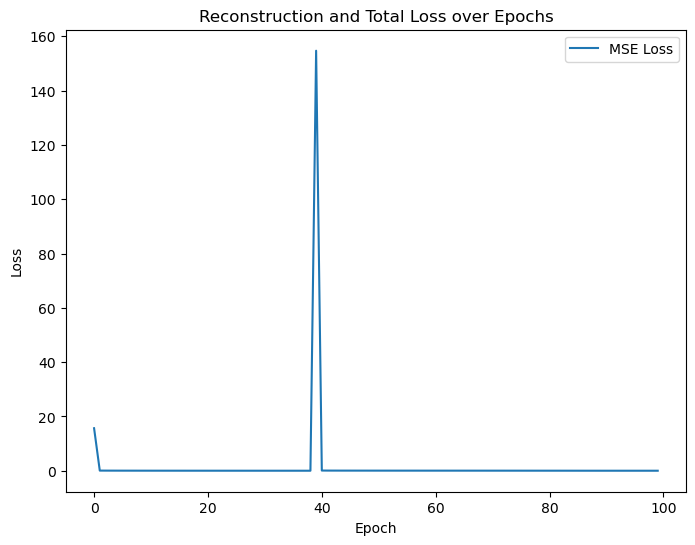

In [25]:
# Plot reconstruction and MSE loss
plt.figure(figsize=(8, 6))
plt.plot(mse_losses, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Reconstruction and Total Loss over Epochs')
plt.legend()
plt.show()

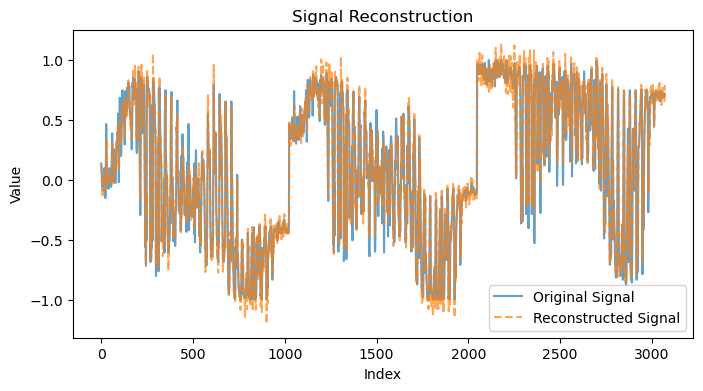

In [26]:
def visualize_signal_reconstruction(model, original_data, reconstruction):
    # Flatten and convert to numpy for signal plot
    original_signal = original_data.numpy().flatten()
    reconstructed_signal = reconstruction.numpy().flatten()

    # Plot original and reconstructed signals
    plt.figure(figsize=(8, 4))
    plt.plot(original_signal, label='Original Signal', alpha=0.7)
    plt.plot(reconstructed_signal, label='Reconstructed Signal', linestyle='--', alpha=0.7)
    plt.title('Signal Reconstruction')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# Take a sample from CIFAR-10
cifar_samples, _ = next(iter(trainloader))

# Visualize the original and reconstructed signals
sample = cifar_samples[0].view(-1)
trained_model.eval()
with torch.no_grad():
    reconstruction, _ = trained_model(sample.unsqueeze(0))
    reconstruction = reconstruction.squeeze(0)

visualize_signal_reconstruction(trained_model, sample, reconstruction)

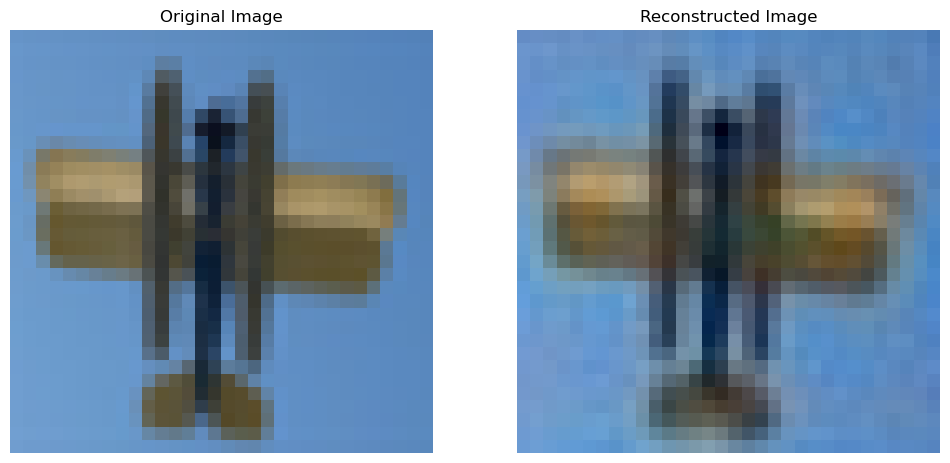

In [27]:
def visualize_reconstruction(original_data, reconstruction):
    # Unnormalize the data
    original_data = original_data.view(3, 32, 32).permute(1, 2, 0) * 0.5 + 0.5
    reconstruction = reconstruction.view(3, 32, 32).permute(1, 2, 0) * 0.5 + 0.5

    # Ensure valid range
    original_data = torch.clamp(original_data, 0, 1).numpy()
    reconstruction = torch.clamp(reconstruction, 0, 1).numpy()

    # Plot original and reconstructed images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_data)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(reconstruction)
    plt.title('Reconstructed Image')
    plt.axis('off')
    plt.show()

# Take a sample from CIFAR-10
cifar_samples, _ = next(iter(trainloader))
sample = cifar_samples[0].view(-1)

trained_model.eval()
with torch.no_grad():
    reconstruction, sparse_codes = trained_model(sample.unsqueeze(0))
    reconstruction = reconstruction.squeeze(0)
    sparse_codes = sparse_codes.squeeze(0).numpy()

# Visualize the original and reconstructed images
visualize_reconstruction(sample, reconstruction)

In [28]:
import math
import numpy as np

# Function to compute PSNR
def compute_psnr(original, reconstructed):
    # Ensure inputs are NumPy arrays
    original = original.detach().cpu().numpy() if isinstance(original, torch.Tensor) else original
    reconstructed = reconstructed.detach().cpu().numpy() if isinstance(reconstructed, torch.Tensor) else reconstructed

    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:  # If MSE is zero, return max PSNR
        return 100
    max_pixel = 1.0  # Assuming images are normalized to [0, 1]
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# Compute PSNR for the sample
psnr_val = compute_psnr(sample, reconstruction)
print(f'PSNR: {psnr_val:.2f} dB')

PSNR: 22.43 dB


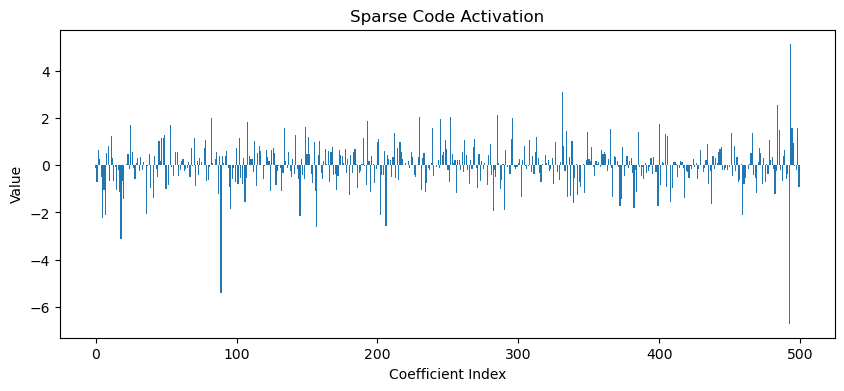

In [29]:
def visualize_results(model, data_sample):
    model.eval()
    with torch.no_grad():
        reconstruction, sparse_codes = model(data_sample.unsqueeze(0))
        reconstruction = reconstruction.squeeze(0)
        sparse_codes = sparse_codes.squeeze(0).numpy()

    # Sparse codes visualization
    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(sparse_codes)), sparse_codes)
    plt.title('Sparse Code Activation')
    plt.xlabel('Coefficient Index')
    plt.ylabel('Value')
    plt.show()


# Visualize the results for a single data sample
visualize_results(trained_model, sample)

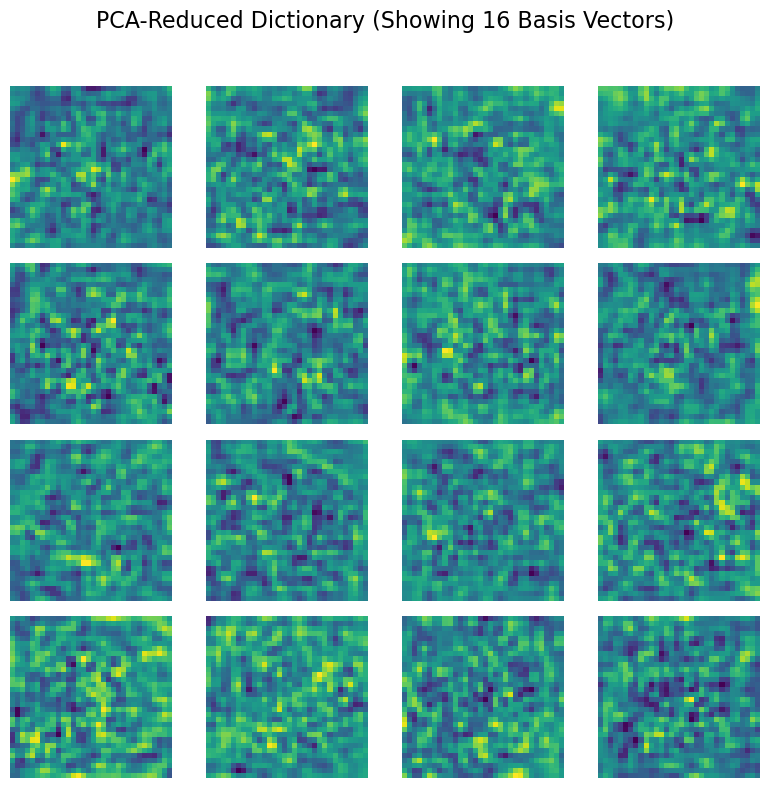

In [34]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def visualize_dictionary(model, num_atoms=16):
    dictionary = model.dictionary.detach().cpu().numpy()  # Shape: (num_original_atoms, 3072)

    # Flatten the dictionary to (num_atoms, 3072)
    flattened_dict = dictionary.reshape(dictionary.shape[0], -1)  # Each atom is now 3072-dimensional

    # Apply PCA to reduce the number of atoms to `num_atoms`
    pca = PCA(n_components=num_atoms)
    reduced_dict = pca.fit(flattened_dict).components_  # Get the top `num_atoms` principal components

    # Reshape each reduced atom to (3, 32, 32)
    projected_dict = reduced_dict.reshape(num_atoms, 3, 32, 32)

    # Calculate grid size for square layout
    grid_size = int(np.ceil(np.sqrt(num_atoms)))

    plt.figure(figsize=(8, 8))  # Adjust size as needed
    for i in range(num_atoms):
        plt.subplot(grid_size, grid_size, i + 1)
        basis_vector = projected_dict[i]

        # Apply min-max normalization to enhance contrast
        min_val, max_val = basis_vector.min(), basis_vector.max()
        basis_vector = (basis_vector - min_val) / (max_val - min_val + 1e-10)  # Avoid division by zero

        # Transpose to (32, 32, 3) and clip to valid range
        basis_vector = basis_vector.transpose(1, 2, 0)[:, :, 0]  # Convert to HWC and RGB
        basis_vector = np.clip(basis_vector, 0, 1)  # Ensure valid range

        plt.imshow(basis_vector)
        plt.axis('off')
    plt.suptitle(f'PCA-Reduced Dictionary (Showing {num_atoms} Basis Vectors)', fontsize=16)
    plt.tight_layout(rect=(0., 0., 1., 0.95))
    plt.show()

# Visualize the learned dictionary with PCA reduction
visualize_dictionary(trained_model)